In [26]:
#imports 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from dtreeviz import model
from sklearn.tree import plot_tree

In [2]:
df=pd.read_csv("MBA.csv")
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=6194, step=1)
All columns are
0 application_id
1 gender
2 international
3 gpa
4 major
5 race
6 gmat
7 work_exp
8 work_industry
9 admission


In [3]:
df.shape

(6194, 10)

In [4]:
df.head()

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
0,1,Female,False,3.30,Business,Asian,620.0,3.0,Financial Services,Admit
1,2,Male,False,3.28,Humanities,Black,680.0,5.0,Investment Management,NaN
2,3,Female,True,3.30,Business,NaN,710.0,5.0,Technology,Admit
3,4,Male,False,3.47,STEM,Black,690.0,6.0,Technology,NaN
4,5,Male,False,3.35,STEM,Hispanic,590.0,5.0,Consulting,NaN


In [5]:
# Filling missing values

# Filling missing race with unknown
df["race"] = df["race"].fillna("Unknown")



# Filling missing admission value with Rejected
df["admission"] = df["admission"].fillna("Rejected")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6194 entries, 0 to 6193
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   application_id  6194 non-null   int64  
 1   gender          6194 non-null   object 
 2   international   6194 non-null   bool   
 3   gpa             6194 non-null   float64
 4   major           6194 non-null   object 
 5   race            6194 non-null   object 
 6   gmat            6194 non-null   float64
 7   work_exp        6194 non-null   float64
 8   work_industry   6194 non-null   object 
 9   admission       6194 non-null   object 
dtypes: bool(1), float64(3), int64(1), object(5)
memory usage: 441.7+ KB


In [7]:
# Dropping application_id
df = df.drop(['application_id'],axis=1)

In [8]:
# function for calculating which product occur multiple times and how much time it occur
def duplicates(column_name):
    counts = df[column_name].value_counts()
    duplicates = counts[counts > 1]
    result = duplicates.reset_index()
    result.columns = [column_name, 'Count']
    print(result)

duplicates("gender")
print()
duplicates("international")
print()
duplicates("major")
print()
duplicates("race")
print()
duplicates("work_exp")
print()
duplicates("work_industry")
print()
duplicates("admission")

   gender  Count
0    Male   3943
1  Female   2251

   international  Count
0          False   4352
1           True   1842

        major  Count
0  Humanities   2481
1        STEM   1875
2    Business   1838

       race  Count
0   Unknown   1842
1     White   1456
2     Asian   1147
3     Black    916
4  Hispanic    596
5     Other    237

   work_exp  Count
0       5.0   2419
1       6.0   1528
2       4.0   1437
3       3.0    369
4       7.0    367
5       8.0     38
6       2.0     32
7       9.0      2
8       1.0      2

            work_industry  Count
0              Consulting   1619
1                   PE/VC    907
2              Technology    716
3           Nonprofit/Gov    651
4      Investment Banking    580
5      Financial Services    451
6                   Other    421
7             Health Care    334
8   Investment Management    166
9                     CPG    114
10            Real Estate    111
11    Media/Entertainment     59
12                 Retail     33
13 

In [9]:
# Label Encoding
label_encoders = {}

for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

In [10]:
df.sample(n=10)

,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
4602,0,False,3.25,2,1,650.0,6.0,6,1
2617,1,False,3.34,1,5,660.0,4.0,1,1
5650,0,True,3.27,2,4,610.0,4.0,1,1
1369,1,False,3.22,1,2,620.0,6.0,0,1
1114,1,False,3.22,2,2,630.0,6.0,1,1
5667,1,False,3.61,1,0,780.0,5.0,1,0
2715,1,False,3.16,0,5,640.0,5.0,1,1
4848,1,False,3.48,2,2,660.0,5.0,1,2
457,1,False,3.43,1,0,640.0,4.0,11,1
3089,0,False,3.27,2,0,610.0,4.0,6,1


In [11]:
X = df.drop(columns=["admission"])
y = df["admission"]

In [12]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [13]:
# Training

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [14]:
y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.778046811945117

Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.34      0.35       196
           1       0.87      0.87      0.87      1025
           2       0.03      0.06      0.04        18

    accuracy                           0.78      1239
   macro avg       0.42      0.42      0.42      1239
weighted avg       0.78      0.78      0.78      1239


Confusion Matrix:
[[ 67 119  10]
 [111 896  18]
 [  5  12   1]]


In [18]:
# Tuning Hyperparameter
model1 = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model1.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [23]:
# base model with general hyperparameter

y_pred = model1.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8224374495560937

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.11      0.18       196
           1       0.84      0.97      0.90      1025
           2       0.00      0.00      0.00        18

    accuracy                           0.82      1239
   macro avg       0.42      0.36      0.36      1239
weighted avg       0.76      0.82      0.77      1239


Confusion Matrix:
[[ 22 174   0]
 [ 28 997   0]
 [  1  17   0]]


C:\Users\abhinavkuriya\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
C:\Users\abhinavkuriya\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
C:\Users\abhinavkuriya\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


C:\Users\abhinavkuriya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


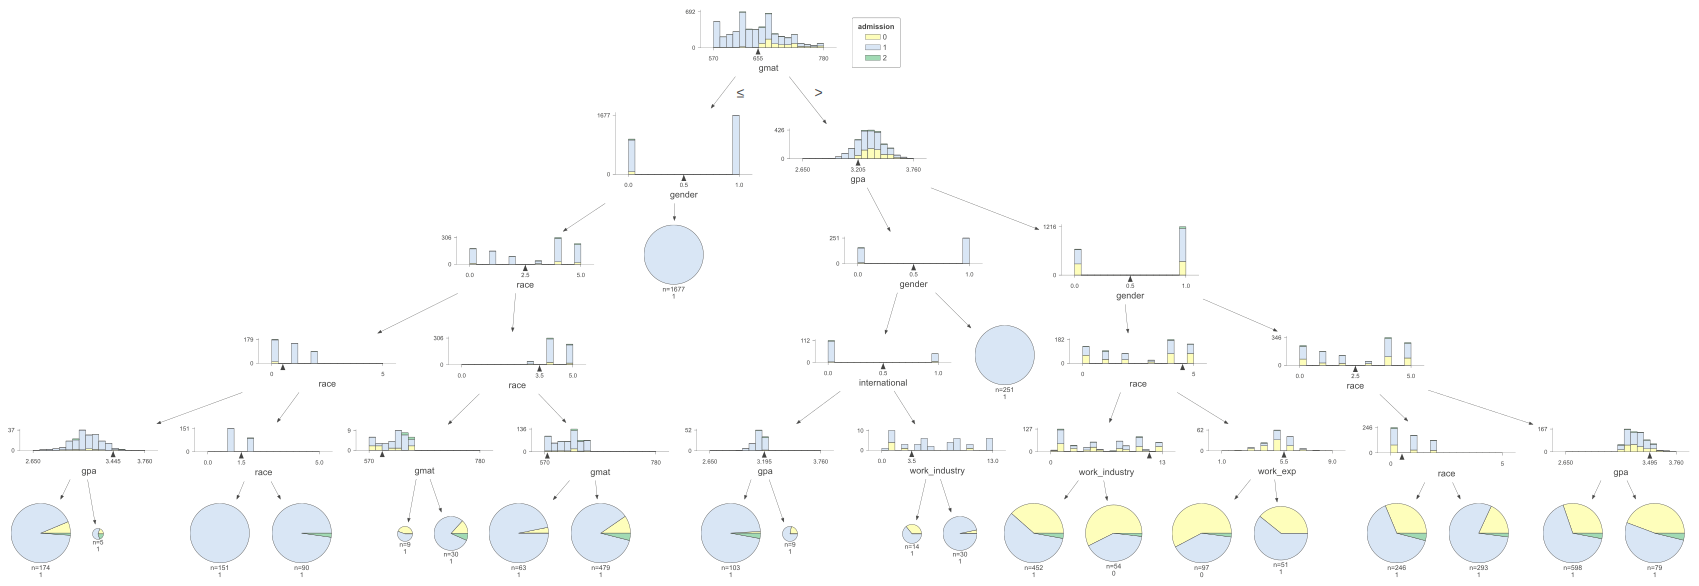

In [24]:
viz = model(
    model= model1,
    X_train=X_train,
    y_train=y_train,
    feature_names=X_train.columns,
    target_name="admission",
    class_names=["0", "1","2"]
)
viz.view()

In [25]:
# For saving the plot
'''

viz.view().save("decisiontree.svg")

'''